In [1]:
from pathlib import Path
import gzip
import json
from pprint import pprint
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
from stable_platform_matchings.domain.instance import Instance

In [2]:
root = Path("../results/exp_1")

all_jsons = list(root.rglob("*.json.gz"))

In [3]:
graph_data_filename = "../data/graph_0-14960_00_new.pickle"
Platform = Instance.from_yaml(Path('../data/anon_14_day_instances/instance_0.yaml'))

In [ ]:
summ_dict = []
for file in all_jsons:
    with gzip.open(file, 'rt', encoding='utf-8') as f:
        payload = json.load(f)
        pprint(payload)
        break
    epsilons = payload["sampled_inputs"]["epsilons"]
    het_costs = payload["sampled_inputs"]["het_costs"]
    intermediaries = payload["summary"]["instance_snapshot"]["intermediaries"]
    max_int_result = payload["summary"]["platform_solve_result"]["max_intermediary_welfare_result"]
    max_farmer_result = payload["summary"]["platform_solve_result"]["max_farmer_welfare_result"]

    for intermediary in intermediaries:
        intermediary_id = intermediary["id"]
        matched = intermediary_id in max_int_result["selected_intermediaries"]

        summ_dict.append({
            "epsilon": epsilons[intermediary_id],
            "quantity": intermediary["status_quo_quantity"],
            "power": epsilons[intermediary_id]+intermediary["status_quo_quantity"],
            "instance_id": payload["summary"]["instance_snapshot"]["instance_id"],
            "intermediary": intermediary_id,
            "matched": float(matched),
            "profit_max": max_int_result["intermediary_profits"][intermediary_id]/ Platform.lc_to_usd,
            "profit_min": max_farmer_result["intermediary_profits"][intermediary_id]/ Platform.lc_to_usd,
        })  

df = pd.DataFrame(summ_dict)


{'experiment_metadata': {'base_seed': 20260806,
                         'constants': {'het_cost_mean': 0.0,
                                       'het_cost_sd': 100000.0,
                                       'max_epsilon': 6.0,
                                       'max_perturb': 0.5,
                                       'max_quantity': 9.0,
                                       'min_epsilon': 0.0,
                                       'min_quantity': 0.1,
                                       'vrp_time_limit_seconds': 1800},
                         'experiment': 'exp_1',
                         'gurobipy_version': '12.0.3',
                         'job_id': 0,
                         'numpy_version': '2.5.1',
                         'python_version': '3.12.7',
                         'solver_threads': 1,
                         'stable_platform_matchings_version': '0.1.0'},
 'metadata': {'instance_file': 'instance_3.yaml',
              'instance_index': 7,
          

In [10]:
df = df.query("power <=12")
df["profit_max_after_payment"] = df["profit_max"] + df["cost"]
df["fixed_cost"] = df["cost"] + 800000
df["fixed_cost"] = df["fixed_cost"]/Platform.lc_to_usd

FileNotFoundError: [Errno 2] No such file or directory: '../figures/matched_heatplot.png'

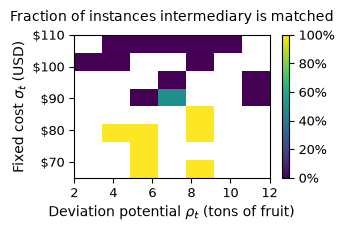

In [11]:
# Define a formatter function for the y-axis
def currency_formatter(x, pos):
    return f'${x:.0f}'


plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

# Create bins for power and cost
power_bins = np.linspace(2, 12, 7)
cost_bins = np.linspace(65, 110, 7)

# Assign bin indices
df['power_bin'] = np.digitize(df['power'], power_bins) - 1
df['cost_bin'] = np.digitize(df['fixed_cost'], cost_bins) - 1

# Compute probability that matched = 1 in each (power, cost) bin
heatmap = df.groupby(['power_bin', 'cost_bin'])['matched'].mean().unstack() * 100  # Convert to percentage

# Plot heatmap
plt.figure(figsize=(3.5, 2.4))
plt.imshow(
    heatmap.T, origin='lower', aspect='auto',
    extent=[power_bins[0], power_bins[-1], cost_bins[0], cost_bins[-1]],
    cmap='viridis'
)
cbar = plt.colorbar()
# Format colorbar ticks as percentages
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.xlabel(r'Deviation potential $\rho_t$ (tons of fruit)')
#plt.xticks(ticks=np.arange(len(power_bins)), labels=[f"{p:.1f}" for p in power_bins], rotation=45)
# Apply the formatter to the y-axis
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_formatter))
plt.ylabel(r'Fixed cost $\sigma_t$ (USD)')
plt.title(r'Fraction of instances intermediary is matched', pad=10)
plt.tight_layout()
plt.savefig("../figures/matched_heatplot.png", bbox_inches='tight', dpi=300)  # INFORMS-compliant
plt.show()


In [19]:
summ_dict = []
for file in all_jsons:
    with gzip.open(file, 'rt', encoding='utf-8') as f:
        payload = json.load(f)
    epsilons = payload["sampled_inputs"]["epsilons"]
    het_costs = payload["sampled_inputs"]["het_costs"]
    quantities = payload["sampled_inputs"]["quantities"]

    farmers = payload["summary"]["instance_snapshot"]["farmers"]
    intermediaries = payload["summary"]["instance_snapshot"]["intermediaries"]
    max_int_result = payload["summary"]["platform_solve_result"]["max_intermediary_welfare_result"]
    max_farmer_result = payload["summary"]["platform_solve_result"]["max_farmer_welfare_result"]

    for farmer in farmers:
        farmer_id = farmer["id"]
        intermediary_id = farmer["intermediary_id"]

        for intermediary in intermediaries:
            if intermediary["id"] == intermediary_id:
                break

        summ_dict.append({
            "epsilon": epsilons,
            "quantity": quantities[farmer_id],
            "instance_id": payload["summary"]["instance_snapshot"]["instance_id"],
            "payment_min": max_int_result["farmer_payments"][farmer_id],
            "payment_max": max_farmer_result["farmer_payments"][farmer_id],
            "farmer_id": farmer_id,
            "dirt_to_mill": farmer["dirt_to_mill"],
            "paved_to_mill": farmer["paved_to_mill"],
            "int_power": epsilons[intermediary_id]+intermediary["status_quo_quantity"],
            "int_matched": max_int_result["intermediary_profits"][intermediary_id] > 10,
            "payment_per_kg": max_int_result["farmer_payments"][farmer_id] / quantities[farmer_id]
        })  

df = pd.DataFrame(summ_dict)


FileNotFoundError: [Errno 2] No such file or directory: '../figures/boxplots_prices.png'

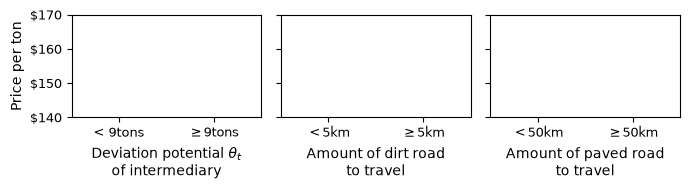

In [21]:
import seaborn as sns

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter

# Update global plot parameters
plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

# Function to format y-axis as dollars
def dollar_formatter(x, pos):
    return f'${int(x)}'

formatter = FuncFormatter(dollar_formatter)

# Change bin labels to Low and High
df['int_power_bin'] = pd.cut(
    df['int_power'],
    bins=[-float('inf'), 9, float('inf')],
    labels=['< 9tons', r'$\geq 9$tons']
)

df['dirt_to_mill_bin'] = pd.cut(
    df['dirt_to_mill'],
    bins=[-float('inf'), 5, float('inf')],
    labels=[r'$< 5$km', r'$\geq 5$km']
)

df['paved_to_mill_bin'] = pd.cut(
    df['paved_to_mill'],
    bins=[-float('inf'), 50, float('inf')],
    labels=[r'$< 50$km', r'$\geq 50$km']
)

# Create a single figure with 3 subplots horizontally
fig, axes = plt.subplots(1, 3, figsize=(7, 2), sharey=True)

# First plot: Power to Deviate
sns.boxplot(
    data=df,
    x='int_power_bin',
    y='payment_per_kg',
    showfliers=False,
    ax=axes[0]
)

axes[0].set_xlabel(r'Deviation potential $\theta_t$'+'\nof intermediary')
axes[0].set_ylabel('Price per ton')
axes[0].set_ylim(130, 170)
axes[0].yaxis.set_major_formatter(formatter)

# Second plot: Dirt road
sns.boxplot(
    data=df,
    x='dirt_to_mill_bin',
    y='payment_per_kg',
    showfliers=False,
    ax=axes[1]
)
axes[1].set_xlabel('Amount of dirt road\nto travel')
axes[1].set_ylabel('')
axes[1].set_ylim(130, 170)
axes[1].yaxis.set_major_formatter(formatter)

# Third plot: Paved road
sns.boxplot(
    data=df,
    x='paved_to_mill_bin',
    y='payment_per_kg',
    showfliers=False,
    ax=axes[2]
)
axes[2].set_xlabel('Amount of paved road\nto travel')
axes[2].set_ylabel('')
axes[2].set_ylim(140, 170)
axes[2].yaxis.set_major_formatter(formatter)

# No shared title this time
plt.tight_layout()
plt.savefig("../figures/boxplots_prices.png", bbox_inches='tight', dpi=300)

plt.show()
